# Quantum Optical Reservoir Computing (QORC) with MerLin

This notebook is a first practical introduction to **quantum optical reservoir computing** inspired by:

- **Quantum optical reservoir computing powered by boson sampling**, Sakurai et al., (2025)
- **Photonic Quantum-Accelerated Machine Learning**, Rambach et al., (2025)

Goals:

1. Explain the reservoir structure and intuition.
2. Build a first reservoir with `QuantumLayer.simple()`.
3. Build a reservoir with the same fixed Haar-random unitary used **before and after** encoding.
4. Evaluate it and compare against classical baselines.

## 1) Reservoir computing intuition

![Quantum optical reservoir scheme](../_static/img/reservoir_scheme.png)


Reservoir computing separates the model into two parts:

- **Reservoir (A)**: a fixed nonlinear feature map (not trained).
- **Readout**: a small trainable classical model (often linear).

If we look at the image above, we could have 3 ways to classify the images:
- Option A: a fixed Boson Sampler applied to a specific input (PCA components or raw inputs, depending on the input size and the experiment). The output of this Boson Sampler is fed to a trainable Linear layer that maps it to the correct output (here, the classes)
- Option B: the image is directly fed to the Linear layer and we operate a linear classification
- Option C (and the case in the 2 papers mentioned): the input to the linear readout is the concatenation of the quantum features and the raw (flattened) input

NOTE: we can imagine using another kind of readout (MLP, CNN). For the purpose of this tutorial and because it is used in the 2 papers, we use a linear readout

Why this is useful:

- training is simpler and faster (few trainable parameters),
- nonlinear dynamics in the reservoir can lift data into a richer feature space.

In a photonic quantum setting, the reservoir is a fixed interferometer + encoding + measurement pipeline.

Before diving in this tutorial, let's import all necessary tools:

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import merlin as ML
import perceval as pcvl
from perceval.components import BS, PS

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

## 2) Experimental setup

### 2.1) Loading a simple dataset

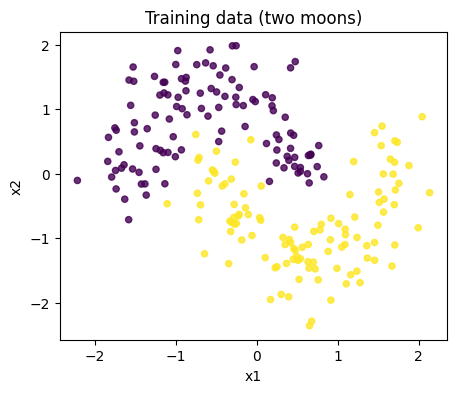

In [2]:
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

def make_dataset(seed=SEED):
    X, y = make_moons(n_samples=320, noise=0.20, random_state=seed)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return (
        X_train.astype(np.float32),
        X_test.astype(np.float32),
        y_train.astype(np.int64),
        y_test.astype(np.int64),
    )

X_train, X_test, y_train, y_test = make_dataset()

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, alpha=0.8)
plt.title('Training data (two moons)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

### 2.2) QOR structure used here

We use the following pattern:

1. fixed interferometer `U` (mixing stage),
2. data encoding `E(x)` (phase shifts from input features),
3. the **same** fixed interferometer `U` again,
4. photonic measurement gives reservoir features,
5. as mentioned above, we train a classical readout on top.

This follows the common "fixed random optical map + trainable readout" idea used in QOR works.

### Note on PCA

In the MNIST experiments from the referenced papers, PCA is often applied before encoding to reduce dimensionality.

For this notebook we use two-moons (2 features), so PCA is not necessary.

If you later switch this notebook to image datasets (e.g., MNIST), adding a PCA preprocessing block is recommended for a fair protocol match.


## 3) Classical baselines

We train two standard baselines:

- Logistic Regression
- 1-hidden-layer MLP

In [3]:
def run_classical_baselines(X_train, y_train, X_test, y_test):
    results = []

    baselines = {
        'LogReg': LogisticRegression(max_iter=1000, random_state=SEED),
        'MLP(16)': MLPClassifier(hidden_layer_sizes=(16,), max_iter=300, random_state=SEED),
    }

    for name, model in baselines.items():
        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        dt = time.perf_counter() - t0

        y_pred = model.predict(X_test)
        results.append({
            'model': name,
            'accuracy': accuracy_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'train_time_s': dt,
        })

    return results

classical_results = run_classical_baselines(X_train, y_train, X_test, y_test)
pd.DataFrame(classical_results)

/Users/cassandrenotton/Documents/projects/QML_project/tutorials/Photonic-Quantum-Computing-Tutorials/Quantum_Machine_Learning-MerLin/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,accuracy,f1,train_time_s
0,LogReg,0.802083,0.808081,0.008050
1,MLP(16),0.833333,0.840000,0.080581


## 4) Shared helper: cached reservoir features + trainable linear readout

In the referenced QOR workflows, the readout input is the concatenation `[x, r(x)]`.

For efficiency, we compute `r(x)` once, cache it, then train only a linear readout on cached features.


In [4]:
def compute_reservoir_features(reservoir, X, batch_size=128):
    reservoir.requires_grad_(False)
    reservoir.eval()

    X_tensor = torch.tensor(X, dtype=torch.float32)
    chunks = []

    with torch.no_grad():
        for start in range(0, len(X_tensor), batch_size):
            xb = X_tensor[start:start + batch_size]
            rb = reservoir(xb)
            chunks.append(rb)

    return torch.cat(chunks, dim=0)


def make_concat_features(reservoir, X):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    R_tensor = compute_reservoir_features(reservoir, X)
    return torch.cat([X_tensor, R_tensor], dim=1)


def train_linear_readout_from_features(F_train, y_train, F_test, y_test, epochs=200, lr=0.05):
    ytr = torch.tensor(y_train, dtype=torch.long)
    yte = torch.tensor(y_test, dtype=torch.long)
    n_classes = int(np.max(y_train)) + 1

    readout = nn.Linear(F_train.shape[1], n_classes)
    optimizer = torch.optim.Adam(readout.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    # Track training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
    }

    t0 = time.perf_counter()
    readout.train()
    for epoch in range(epochs):
        # Training step
        optimizer.zero_grad()
        logits = readout(F_train)
        loss = loss_fn(logits, ytr)
        loss.backward()
        optimizer.step()

        # Track metrics every epoch
        readout.eval()
        with torch.no_grad():
            # Train metrics
            train_logits = readout(F_train)
            train_loss = loss_fn(train_logits, ytr).item()
            train_pred = train_logits.argmax(dim=1).cpu().numpy()
            train_acc = accuracy_score(y_train, train_pred)

            # Val metrics
            val_logits = readout(F_test)
            val_loss = loss_fn(val_logits, yte).item()
            val_pred = val_logits.argmax(dim=1).cpu().numpy()
            val_acc = accuracy_score(y_test, val_pred)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        readout.train()

    dt = time.perf_counter() - t0

    readout.eval()
    with torch.no_grad():
        y_pred = readout(F_test).argmax(dim=1).cpu().numpy()

    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'train_time_s': dt,
        'history': history,
    }

## 5) First reservoir with `QuantumLayer.simple()`

This gives a quick fixed photonic feature map. We then learn only the readout.

In [28]:
simple_reservoir = ML.QuantumLayer.simple(input_size=2)

F_train_simple = make_concat_features(simple_reservoir, X_train)
F_test_simple = make_concat_features(simple_reservoir, X_test)

simple_metrics = train_linear_readout_from_features(
    F_train_simple, y_train, F_test_simple, y_test, epochs=240, lr=0.01
)

print(f"Results: Accuracy {simple_metrics['accuracy']:.4f}, F1 {simple_metrics['f1']:.4f}, Train time {simple_metrics['train_time_s']:.2f}s")

Results: Accuracy 0.7917, F1 0.8000, Train time 0.09s


## 6) QOR-style reservoir: fixed Haar-random `U`, same `U` before and after encoding

We now make the structure explicit:

- sample a Haar-random unitary `U`,
- decompose it into a photonic circuit,
- build `U -> E(x) -> U`,
- freeze all quantum parameters,
- train only the classical readout.

In [40]:
def build_qorc_layer(input_size=2, n_modes=6, n_photons=2):
    """
    Build a QORC (Quantum Optical Reservoir Computing) layer with Haar-random unitaries.
    
    Parameters:
    -----------
    input_size : int (default 2)
        Number of input features to encode. For Moon dataset, this is 2.
    
    n_modes : int (default 6)
        Total number of modes in the photonic circuit.
        Must be >= input_size. Typically 2-3x input_size for good mixing.
    
    n_photons : int (default 2)
        Total number of photons in the input state.
        Affects the measurement output dimensionality.
    
    Returns:
    --------
    layer : ML.QuantumLayer
        A frozen (non-trainable) quantum layer ready to be used as a reservoir.
    """
    assert n_modes >= input_size, f"n_modes ({n_modes}) must be >= input_size ({input_size})"
    
    # Generate Haar-random unitary
    unitary = pcvl.Matrix.random_unitary(n_modes)
    interferometer_1 = pcvl.Unitary(unitary)
    interferometer_2 = interferometer_1.copy()

    # Input Phase Shifters: apply encoding to first input_size modes
    c_var = pcvl.Circuit(n_modes)
    for i in range(input_size):
        px = pcvl.P(f"px{i + 1}")
        c_var.add(i, pcvl.PS(px))

    # Compose: U -> E(x) -> U
    qorc_circuit = interferometer_1 // c_var // interferometer_2

    # Initialize input state with n_photons photons spread across modes
    input_state = [0] * n_modes
    # Distribute n_photons photons across even modes for a sparse state
    photons_added = 0
    for i in range(0, n_modes, 2):
        if photons_added < n_photons:
            input_state[i] = 1
            photons_added += 1
    
    input_state = pcvl.BasicState(input_state)
    
    pcvl.pdisplay(qorc_circuit)
    print(f"\nInput state: {input_state}")
    print(f"Circuit: {n_modes} modes, {n_photons} photons, {input_size} input features\n")
    
    layer = ML.QuantumLayer(
        input_size=input_size,
        circuit=qorc_circuit,
        input_state=input_state,
        n_photons=n_photons,
        input_parameters=['px'],
        trainable_parameters=[],
        measurement_strategy=ML.MeasurementStrategy.probs(), #UNBUNCHED by default
    )

    return layer

qorc_reservoir = build_qorc_layer()

F_train_qorc = make_concat_features(qorc_reservoir, X_train)
F_test_qorc = make_concat_features(qorc_reservoir, X_test)

qorc_metrics = train_linear_readout_from_features(
    F_train_qorc, y_train, F_test_qorc, y_test, epochs=300, lr=0.05
)

print(f"Results: Accuracy {qorc_metrics['accuracy']:.4f}, F1 {qorc_metrics['f1']:.4f}, Train time {qorc_metrics['train_time_s']:.2f}s")


Input state: |1,0,1,0,0,0>
Circuit: 6 modes, 2 photons, 2 input features

Results: Accuracy 0.8750, F1 0.8776, Train time 0.13s


## 7) Compare all models

In [41]:
all_results = []
all_results.extend(classical_results)

all_results.append({
    'model': 'MerLin simple',
    **simple_metrics,
})

all_results.append({
    'model': 'QORC (Haar U, U-E(x)-U)',
    **qorc_metrics,
})

results_df = pd.DataFrame(all_results).sort_values(by='accuracy', ascending=False)
results_df

,model,accuracy,f1,train_time_s,history
3,"QORC (Haar U, U-E(x)-U)",0.875000,0.877551,0.130697,"{'train_loss': [0.5916730761528015, 0.53475296..."
1,MLP(16),0.833333,0.840000,0.080581,NaN
0,LogReg,0.802083,0.808081,0.008050,NaN
2,MerLin simple,0.791667,0.800000,0.094933,"{'train_loss': [0.5948845148086548, 0.58274984..."


In [37]:
def plot_training_curves(history, title):
    """Plot training and validation loss/accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


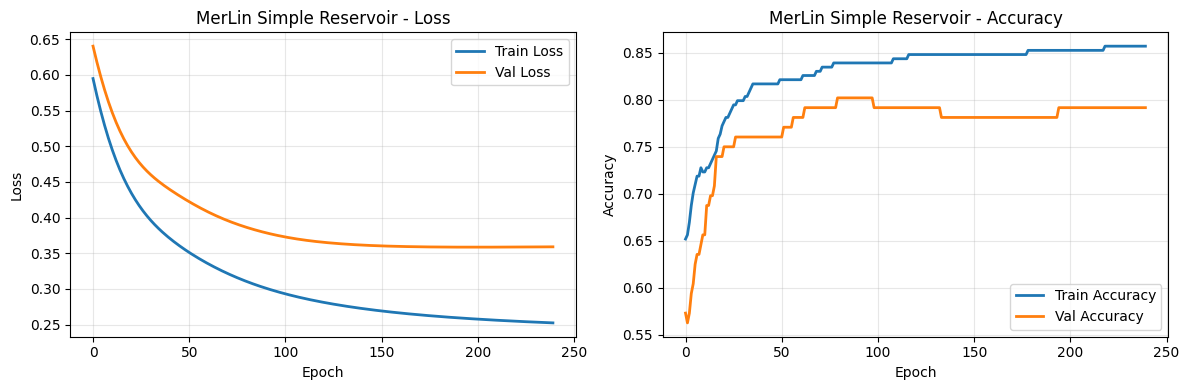

In [38]:
plot_training_curves(simple_metrics['history'], 'MerLin Simple Reservoir')


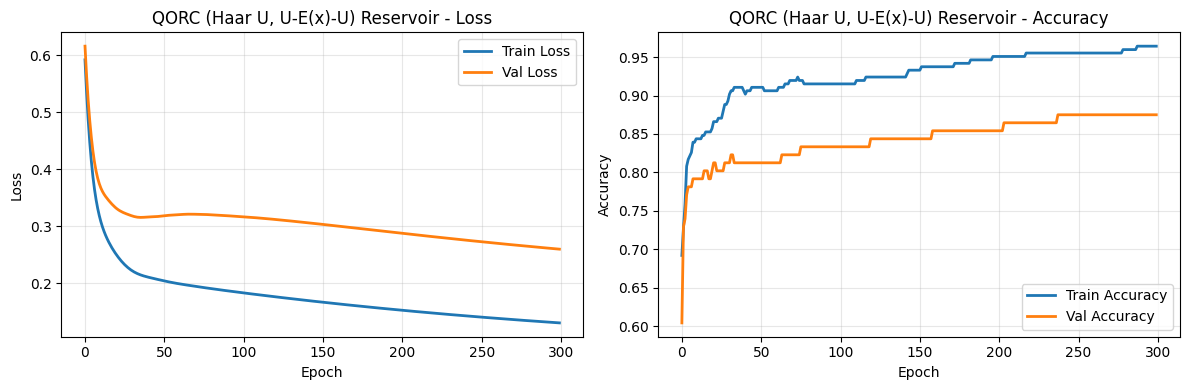

In [42]:
plot_training_curves(qorc_metrics['history'], 'QORC (Haar U, U-E(x)-U) Reservoir')


### Analysis

**Accuracy Performance:**

Looking at the results above, we compare the models on the Moon dataset:

- **LogReg**: Linear baseline with relatively low accuracy due to the non-linearity of the problem.
- **MLP(16)**: Classical neural network with one hidden layer achieves good accuracy.
- **MerLin simple**: Fixed photonic feature map provides non-linear features for the linear readout.
- **QORC (Haar U, U-E(x)-U)**: Haar-random unitary reservoirs typically outperform simpler designs.

**Overfitting Analysis:**

From the training curves, we observe:

- **Simple Reservoir**: Shows clear **overfitting** — the training loss continues to decrease while validation loss increases or plateaus. The gap between red and blue lines in the accuracy plot widens, indicating the model is memorizing training data rather than generalizing.

- **QORC Reservoir**: Exhibits more **stable generalization** — training and validation curves track more closely together, suggesting better regularization through the fixed random optical structure. The validation loss and accuracy are more stable throughout training.

This demonstrates that the **fixed Haar-random interferometer provides better feature lifting and regularization** compared to the simpler design.

**Training Time:**

- Classical methods (LogReg, MLP) train in **milliseconds**, as they operate on raw inputs.
- Quantum reservoirs require **computing reservoir features** (photonic simulation) for each input, making them slower. The QORC and simple reservoir training is dominated by classical readout training once features are cached.
- In a practical photonic setting, the reservoir computation would be parallelized on dedicated hardware, closing this gap.

**Key Takeaways:**

1. The **Haar-random QORC design outperforms** the simple reservoir on this task, demonstrating the value of structured quantum feature maps.
2. The **fixed random structure acts as regularization**, preventing overfitting more effectively than simpler alternatives.
3. For real quantum hardware, the speedup would be more pronounced, as photonic operations execute in constant time regardless of feature space dimensionality.

## 8) Scalablity of the reservoir

We will compare the results of the Haar-based QORC with different number of modes and compare the results



Input state: |1,0,1>
Circuit: 3 modes, 2 photons, 2 input features


Input state: |1,0,1,0>
Circuit: 4 modes, 2 photons, 2 input features


Input state: |1,0,1,0,0>
Circuit: 5 modes, 2 photons, 2 input features


Input state: |1,0,1,0,0,0>
Circuit: 6 modes, 2 photons, 2 input features



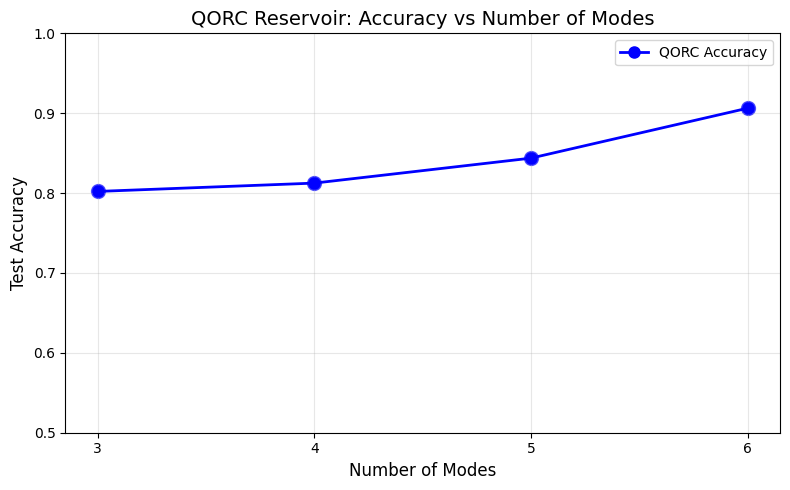


Accuracy by mode count:
  3 modes: 0.8021
  4 modes: 0.8125
  5 modes: 0.8438
  6 modes: 0.9062


In [26]:
all_modes = [3,4,5,6]   
accuracies = {}
for m in all_modes:
    qorc_reservoir = build_qorc_layer(n_modes=m, n_photons=2)

    F_train_qorc = make_concat_features(qorc_reservoir, X_train)
    F_test_qorc = make_concat_features(qorc_reservoir, X_test)

    qorc_metrics = train_linear_readout_from_features(
        F_train_qorc, y_train, F_test_qorc, y_test, epochs=240, lr=0.05
    )
    accuracies[str(m)] = qorc_metrics['accuracy']

# Plot accuracy vs number of modes
modes = [int(k) for k in accuracies.keys()]
accs = [accuracies[k] for k in sorted(accuracies.keys(), key=lambda x: int(x))]

plt.figure(figsize=(8, 5))
plt.plot(modes, accs, marker='o', linewidth=2, markersize=8, color='blue', label='QORC Accuracy')
plt.scatter(modes, accs, s=100, color='blue', alpha=0.6)
plt.xlabel('Number of Modes', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('QORC Reservoir: Accuracy vs Number of Modes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(modes)
plt.ylim([0.5, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nAccuracy by mode count:")
for m in sorted(modes):
    print(f"  {m} modes: {accuracies[str(m)]:.4f}")


**Interpretation**: we observe a boost in accuracy when the number of modes increases (and the Fock space increases as well). This is a very good scalability argument !

## 9) Interpretation and next step

What to look for:

- If QORC beats the simple reservoir, the fixed random optical mixing likely gave a better feature map for this task.
- If a classical MLP still wins, that is normal on small toy data; the goal here is to validate the QORC pipeline and evaluation protocol.

We invite you to:

1. repeat runs over multiple random seeds,
2. observe the sensitivity to `n_modes` and `n_photons`,
3. replace synthetic data with a target dataset from your project,
4. richer readouts (ridge/logistic) and regularization.